In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

reddit_posts = pd.read_csv('revolut_reddit_posts.csv')
reddit_comments = pd.read_csv('revolut_reddit_comments.csv')
trustpilot = pd.read_csv('revolut_trustpilot_reviews.csv')

print(reddit_posts.head())
print(reddit_comments.head())
print(trustpilot.head())

   post_id                                              title  \
0  1oqo6lz               Do not trust Revolut with your money   
1  1ots2dq  My honest take after 2 years using Revolut as ...   
2  1nmx9jx                   Revolut became a total disgrace!   
3  1md7xg4                              WARNING ABOUT REVOLUT   
4  1qpqqud  Irish minister grilling Revolut executive over...   

                                                text                author  \
0  I've been a paying premium customer for over f...       AlphaMaster1337   
1  Hey everyone,\n\nI don’t post often here and I...  Alternative_Kale_295   
2  I made an emergency transfer of £2400 to my fr...               Loshmie   
3  Im going to be brief. Revolut restricted my ac...  Dull_Examination_132   
4  Irish minister grilling Revolut executive over...    DonkeyOfWallStreet   

   score  upvote_ratio  num_comments                 date  \
0    328          0.85           300  2025-11-07 07:35:08   
1    291          

In [ ]:
# DATA CLEANING


# Combine Reddit posts and comments into one dataset
reddit_text = pd.concat([
    reddit_posts['text'],
    reddit_comments['text']
], ignore_index=True)

# Extract Trustpilot text
trustpilot_text = trustpilot['text']

# Create structured datasets with source labels
df_reddit = pd.DataFrame({
    'text': reddit_text,
    'source': 'Reddit'
})

df_trustpilot = pd.DataFrame({
    'text': trustpilot_text,
    'source': 'Trustpilot'
})

# Merge both datasets
df = pd.concat([df_reddit, df_trustpilot], ignore_index=True)

# Remove missing values
df = df.dropna(subset=['text'])

# Remove empty or whitespace-only rows
df = df[df['text'].str.strip() != ""]

# Remove duplicate texts
df = df.drop_duplicates(subset=['text'])

# Reset index after cleaning
df = df.reset_index(drop=True)

# Check size after cleaning
print("Total rows after cleaning:", len(df))

print(df['source'].value_counts())
print(df['source'].value_counts(normalize=True) * 100)
df.head()


Total rows after cleaning: 2620
source
Reddit        2404
Trustpilot     216
Name: count, dtype: int64
source
Reddit        91.755725
Trustpilot     8.244275
Name: proportion, dtype: float64


,text,source
0,I've been a paying premium customer for over f...,Reddit
1,"Hey everyone,\n\nI don’t post often here and I...",Reddit
2,I made an emergency transfer of £2400 to my fr...,Reddit
3,Im going to be brief. Revolut restricted my ac...,Reddit
4,Irish minister grilling Revolut executive over...,Reddit


In [ ]:
# DATA PREPROCESSING

import re
import nltk

# Download required resources (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize stopwords
stop_words = set(stopwords.words('english'))

# Add domain-specific stopwords
custom_stopwords = {
    "revolut", "bank", "account", "card", "money",
    "use", "using", "also", "one", "get", "got",
    "would", "could", "even", "really",
    "im", "ive", "dont", "cant", "didnt"
}

stop_words = stop_words.union(custom_stopwords)

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Step 1: Clean raw text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'\d+', '', text)              # remove numbers
    text = re.sub(r'[^\w\s]', '', text)          # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

# Step 2: Tokenize + remove stopwords + lemmatize
def preprocess_text(text):
    tokens = text.split()

    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

# Apply preprocessing correctly

# Create clean_text column (IMPORTANT for BERTopic)
df['clean_text'] = df['text'].apply(clean_text)

# Create tokens column (IMPORTANT for LDA)
df['tokens'] = df['clean_text'].apply(preprocess_text)

# Remove empty rows
df = df[df['tokens'].map(len) > 3]

# Remove duplicate texts (based on cleaned text)
df = df.drop_duplicates(subset=['clean_text'])

# Reset index
df = df.reset_index(drop=True)

# Check result
print("Final dataset size:", len(df))
print(df[['text', 'clean_text', 'tokens']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Final dataset size: 2264
                                                text  \
0  I've been a paying premium customer for over f...   
1  Hey everyone,\n\nI don’t post often here and I...   
2  I made an emergency transfer of £2400 to my fr...   
3  Im going to be brief. Revolut restricted my ac...   
4  Irish minister grilling Revolut executive over...   

                                          clean_text  \
0  ive been a paying premium customer for over fi...   
1  hey everyone i dont post often here and i dont...   
2  i made an emergency transfer of to my friend t...   
3  im going to be brief revolut restricted my acc...   
4  irish minister grilling revolut executive over...   

                                              tokens  
0  [paying, premium, customer, five, year, recent...  
1  [hey, everyone, post, often, work, keep, seein...  
2  [made, emergency, transfer, friend, currently,...  
3  [going, brief, restricted, ongoing, total, day...  
4  [irish, minister, grill

In [ ]:
# CLEANED DATA


# Save full cleaned dataset
df.to_csv('cleaned_all_data.csv', index=False)

# Save separate datasets for comparison later
df_reddit_clean = df[df['source'] == 'Reddit']
df_trustpilot_clean = df[df['source'] == 'Trustpilot']

df_reddit_clean.to_csv('cleaned_reddit.csv', index=False)
df_trustpilot_clean.to_csv('cleaned_trustpilot.csv', index=False)

print("Files saved successfully")

Files saved successfully


In [ ]:
# COMBINED LDA


import warnings
warnings.filterwarnings("ignore")

!pip install gensim

import gensim
from gensim import corpora

# Create dictionary
dictionary = corpora.Dictionary(df['tokens'])

# Better filtering (IMPORTANT)
dictionary.filter_extremes(no_below=10, no_above=0.4)

# Create corpus
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

# Train LDA model
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=7,          # increased topics for better separation
    random_state=42,
    passes=15,
    alpha='auto'
)

from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model,
    texts=df['tokens'],
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()
print("Coherence Score:", coherence_score)


Coherence Score: 0.35702059514603485


In [ ]:
print(df.columns)

Index(['text', 'source', 'clean_text', 'tokens'], dtype='object')


In [ ]:
# LDA TOPICS

# Print topics clearly
for idx, topic in lda_model.print_topics(-1):
    print(f"\nTopic {idx}:")
    print(topic)


Topic 0:
0.014*"saving" + 0.013*"month" + 0.011*"credit" + 0.011*"plan" + 0.011*"year" + 0.011*"fee" + 0.010*"good" + 0.009*"like" + 0.008*"account" + 0.008*"option"

Topic 1:
0.020*"transaction" + 0.017*"like" + 0.016*"app" + 0.016*"online" + 0.015*"see" + 0.012*"thing" + 0.012*"never" + 0.011*"issue" + 0.011*"banking" + 0.009*"people"

Topic 2:
0.014*"support" + 0.013*"day" + 0.011*"month" + 0.009*"still" + 0.009*"fund" + 0.009*"customer" + 0.008*"week" + 0.008*"year" + 0.007*"time" + 0.007*"document"

Topic 3:
0.019*"like" + 0.014*"year" + 0.013*"financial" + 0.012*"bank" + 0.012*"youre" + 0.011*"much" + 0.010*"fund" + 0.009*"service" + 0.009*"people" + 0.009*"need"

Topic 4:
0.034*"phone" + 0.025*"xiaomi" + 0.022*"work" + 0.018*"app" + 0.014*"fine" + 0.012*"issue" + 0.012*"thats" + 0.012*"problem" + 0.011*"device" + 0.010*"never"

Topic 5:
0.060*"easy" + 0.028*"currency" + 0.021*"rate" + 0.020*"transfer" + 0.019*"exchange" + 0.018*"great" + 0.014*"app" + 0.013*"fee" + 0.013*"abroa

In [ ]:
# SEPARATE LDA

# Split datasets
df_reddit = df[df['source'] == 'Reddit']
df_trustpilot = df[df['source'] == 'Trustpilot']


def run_lda(data, num_topics=5):
    dictionary = corpora.Dictionary(data['tokens'])
    dictionary.filter_extremes(no_below=5, no_above=0.5)

    corpus = [dictionary.doc2bow(text) for text in data['tokens']]

    model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=10,
        random_state=42
    )

    print("\nTopics:\n")
    for idx, topic in model.print_topics(-1):
        print(f"Topic {idx}: {topic}")

    return model

print("REDDIT TOPICS")
lda_reddit = run_lda(df_reddit, 5)

print("\nTRUSTPILOT TOPICS")
lda_trustpilot = run_lda(df_trustpilot, 5)

REDDIT TOPICS

Topics:

Topic 0: 0.013*"year" + 0.008*"never" + 0.007*"saving" + 0.007*"like" + 0.007*"time" + 0.007*"month" + 0.006*"fee" + 0.006*"etc" + 0.006*"fund" + 0.006*"credit"
Topic 1: 0.018*"like" + 0.011*"data" + 0.010*"roaming" + 0.010*"plus" + 0.009*"plan" + 0.009*"used" + 0.009*"friend" + 0.009*"thing" + 0.009*"something" + 0.008*"thats"
Topic 2: 0.016*"support" + 0.014*"customer" + 0.013*"day" + 0.012*"app" + 0.010*"time" + 0.008*"like" + 0.008*"case" + 0.007*"need" + 0.007*"without" + 0.007*"want"
Topic 3: 0.046*"xiaomi" + 0.046*"phone" + 0.025*"work" + 0.019*"fine" + 0.017*"issue" + 0.016*"pro" + 0.014*"android" + 0.012*"play" + 0.011*"problem" + 0.010*"note"
Topic 4: 0.011*"like" + 0.010*"payment" + 0.010*"back" + 0.009*"transfer" + 0.009*"know" + 0.009*"business" + 0.008*"way" + 0.008*"transaction" + 0.008*"make" + 0.007*"pay"

TRUSTPILOT TOPICS

Topics:

Topic 0: 0.082*"great" + 0.067*"free" + 0.051*"banking" + 0.044*"simple" + 0.040*"feel" + 0.040*"currency" + 0.03

In [ ]:
# COMBINED VISUALISATION

!pip install pyLDAvis

import pyLDAvis
import pyLDAvis.gensim_models

# Visualise topics (interactive)
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Recreate dictionary and corpus EXACTLY like during training
dictionary_reddit = corpora.Dictionary(df_reddit['tokens'])
dictionary_reddit.filter_extremes(no_below=5, no_above=0.5)

corpus_reddit = [dictionary_reddit.doc2bow(text) for text in df_reddit['tokens']]

# Now visualise
import pyLDAvis.gensim_models
import pyLDAvis

vis_reddit = pyLDAvis.gensim_models.prepare(
    lda_reddit,
    corpus_reddit,
    dictionary_reddit
)

pyLDAvis.display(vis_reddit)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

dictionary_tp = corpora.Dictionary(df_trustpilot['tokens'])
dictionary_tp.filter_extremes(no_below=5, no_above=0.5)

corpus_tp = [dictionary_tp.doc2bow(text) for text in df_trustpilot['tokens']]

vis_tp = pyLDAvis.gensim_models.prepare(
    lda_trustpilot,
    corpus_tp,
    dictionary_tp
)

pyLDAvis.display(vis_tp)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Install BERTopic
!pip install bertopic

'''from bertopic import BERTopic

# BERTopic works on raw cleaned text (not tokens)
texts = df['clean_text'].tolist()

# Create model
topic_model = BERTopic(verbose=True)

# Fit model
topics, probs = topic_model.fit_transform(texts)

# Add topics to dataframe
df['bertopic'] = topics

# View topics
topic_model.get_topic_info().head()

from bertopic import BERTopic

# Create model
topic_model = BERTopic(verbose=True)

# Fit model
topics, probs = topic_model.fit_transform(texts)

# 🔥 STEP 1: Reduce number of topics
topic_model.reduce_topics(texts, nr_topics=8)

# 🔥 STEP 2: Reassign topics after reduction
new_topics, _ = topic_model.transform(texts)
df['bertopic'] = new_topics

# 🔥 STEP 3: Check topic distribution
print(df['bertopic'].value_counts().head())

# 🔥 STEP 4: Remove outliers (-1 topic)
df_filtered = df[df['bertopic'] != -1]

print("Filtered dataset size:", len(df_filtered))'''

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(stop_words='english')

topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    min_topic_size=20,
    verbose=True
)

topics, probs = topic_model.fit_transform(texts)
df['bertopic'] = topics


# Check distribution
print(df['bertopic'].value_counts())

2026-04-22 03:39:33,562 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

2026-04-22 03:41:29,313 - BERTopic - Embedding - Completed ✓
2026-04-22 03:41:29,315 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-22 03:41:43,868 - BERTopic - Dimensionality - Completed ✓
2026-04-22 03:41:43,870 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 03:41:43,979 - BERTopic - Cluster - Completed ✓
2026-04-22 03:41:43,988 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 03:41:44,162 - BERTopic - Representation - Completed ✓


bertopic
-1     1021
 0      141
 1      131
 2      115
 3      105
 4      101
 5       93
 6       64
 7       61
 8       53
 9       51
 10      48
 11      42
 12      37
 13      33
 14      33
 15      32
 16      28
 17      27
 18      26
 19      22
Name: count, dtype: int64


In [ ]:
# Show top words per topic
for topic in topic_model.get_topics():
    print(f"\nTopic {topic}:")
    print(topic_model.get_topic(topic))


Topic -1:
[('revolut', np.float64(0.027594000323988295)), ('account', np.float64(0.024699364800043064)), ('money', np.float64(0.020522663463677555)), ('bank', np.float64(0.019223599666186725)), ('card', np.float64(0.016331445832422315)), ('im', np.float64(0.01546990915379055)), ('just', np.float64(0.015232641476590206)), ('use', np.float64(0.014851946086576086)), ('like', np.float64(0.01421983668720178)), ('dont', np.float64(0.013453861192811162))]

Topic 0:
[('xiaomi', np.float64(0.07921854421093971)), ('app', np.float64(0.07218976030081381)), ('phone', np.float64(0.07207413665601477)), ('rooted', np.float64(0.059190613427757395)), ('update', np.float64(0.056462616509016274)), ('device', np.float64(0.0528145134287585)), ('android', np.float64(0.05110441544563758)), ('bootloader', np.float64(0.04618251181780297)), ('firmware', np.float64(0.044404273322783634)), ('fine', np.float64(0.04090700810583828))]

Topic 1:
[('revolut', np.float64(0.03240836047318365)), ('account', np.float64(0.

In [ ]:
topic_model.visualize_topics()

In [ ]:
# SENTIMENT ANALYSIS (VADER)

# Install and setup
!pip install nltk

import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize model
sia = SentimentIntensityAnalyzer()

# Function to classify sentiment
def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']

    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis
df['sentiment'] = df['text'].apply(get_sentiment)

df_filtered = df[df['bertopic'] != -1]

# Check output
df[['text', 'sentiment']].head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,text,sentiment
0,I've been a paying premium customer for over f...,Positive
1,"Hey everyone,\n\nI don’t post often here and I...",Positive
2,I made an emergency transfer of £2400 to my fr...,Positive
3,Im going to be brief. Revolut restricted my ac...,Negative
4,Irish minister grilling Revolut executive over...,Neutral


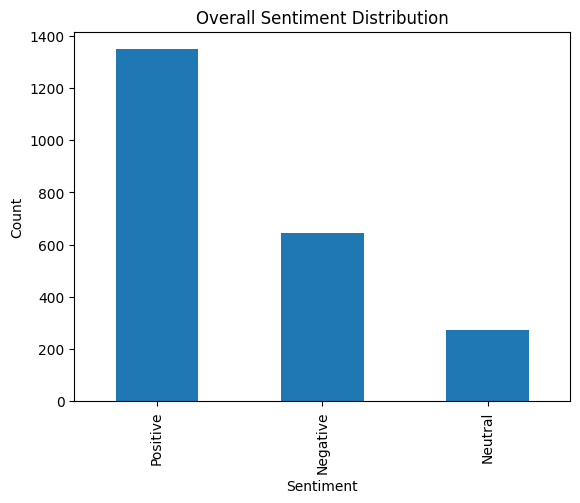

In [ ]:
# OVERALL SENTIMENT DISTRIBUTION

import matplotlib.pyplot as plt

# Count sentiment
sentiment_counts = df['sentiment'].value_counts()

# Plot
sentiment_counts.plot(kind='bar')
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

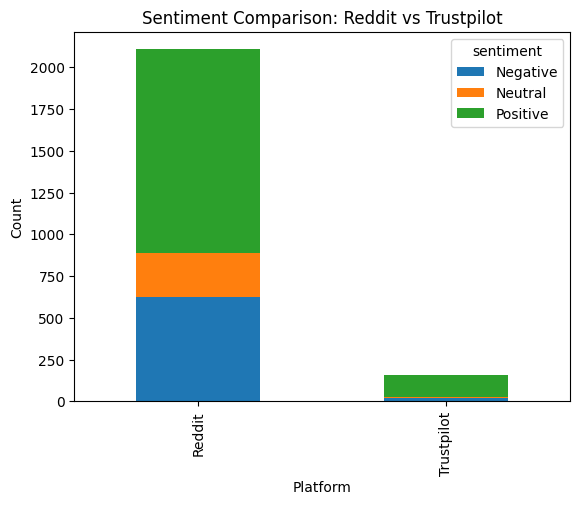

In [ ]:
# REDDIT vs TRUSTPILOT SENTIMENT

# Compare sentiment by platform
comparison = df.groupby(['source', 'sentiment']).size().unstack()

comparison.plot(kind='bar', stacked=True)
plt.title("Sentiment Comparison: Reddit vs Trustpilot")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.show()

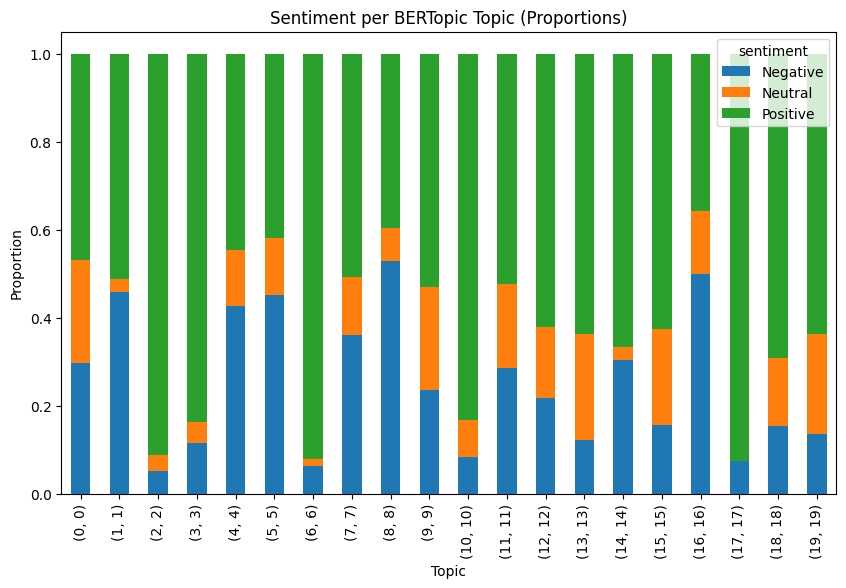

In [ ]:
# SENTIMENT ANALYSIS - BERTOPIC

# Sentiment per BERTopic topic


topic_sentiment_pct = df_filtered.groupby(['bertopic', 'sentiment']).size().groupby(level=0).apply(lambda x: x / x.sum())

topic_sentiment_pct.unstack().plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Sentiment per BERTopic Topic (Proportions)")
plt.xlabel("Topic")
plt.ylabel("Proportion")
plt.show()

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

# ======================
# SAVE DATASETS
# ======================

df.to_csv('final_dataset.csv', index=False)
df_filtered.to_csv('filtered_dataset.csv', index=False)

df_reddit_clean.to_csv('cleaned_reddit.csv', index=False)
df_trustpilot_clean.to_csv('cleaned_trustpilot.csv', index=False)

# ======================
# SAVE BERTOPIC OUTPUT
# ======================

topic_model.get_topic_info().to_csv("bertopic_topics.csv", index=False)

# ======================
# SAVE PLOTS
# ======================

# Overall sentiment
sentiment_counts.plot(kind='bar')
plt.title("Overall Sentiment Distribution")
plt.savefig("sentiment_overall.png", bbox_inches='tight')
plt.close()

# Normalised Reddit vs Trustpilot
comparison_pct = df.groupby(['source', 'sentiment']).size().groupby(level=0).apply(lambda x: x / x.sum())
comparison_pct.unstack().plot(kind='bar', stacked=True)
plt.title("Sentiment Comparison (Normalised)")
plt.savefig("sentiment_comparison_normalised.png", bbox_inches='tight')
plt.close()

# Sentiment per topic (counts)
topic_sentiment = df_filtered.groupby(['bertopic', 'sentiment']).size().unstack()
topic_sentiment.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Sentiment per BERTopic Topic")
plt.savefig("sentiment_per_topic_counts.png", bbox_inches='tight')
plt.close()

# Sentiment per topic (PROPORTIONS — most important)
topic_sentiment_pct = df_filtered.groupby(['bertopic', 'sentiment']).size().groupby(level=0).apply(lambda x: x / x.sum())
topic_sentiment_pct.unstack().plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Sentiment per BERTopic Topic (Proportions)")
plt.savefig("sentiment_per_topic_proportions.png", bbox_inches='tight')
plt.close()

# ======================
# DOWNLOAD ALL FILES
# ======================

file_list = [
    'final_dataset.csv',
    'filtered_dataset.csv',
    'cleaned_reddit.csv',
    'cleaned_trustpilot.csv',
    'bertopic_topics.csv',
    'sentiment_overall.png',
    'sentiment_comparison_normalised.png',
    'sentiment_per_topic_counts.png',
    'sentiment_per_topic_proportions.png'
]

for file in file_list:
    try:
        files.download(file)
    except:
        print(f"{file} not found, skipped")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
source_counts = df['source'].value_counts()

print("Reddit:", source_counts.get('Reddit', 0))
print("Trustpilot:", source_counts.get('Trustpilot', 0))

Reddit: 2106
Trustpilot: 158


In [ ]:
source_percent = df['source'].value_counts(normalize=True) * 100
print(source_percent)

source
Reddit        93.021201
Trustpilot     6.978799
Name: proportion, dtype: float64


<Axes: xlabel='source,source'>

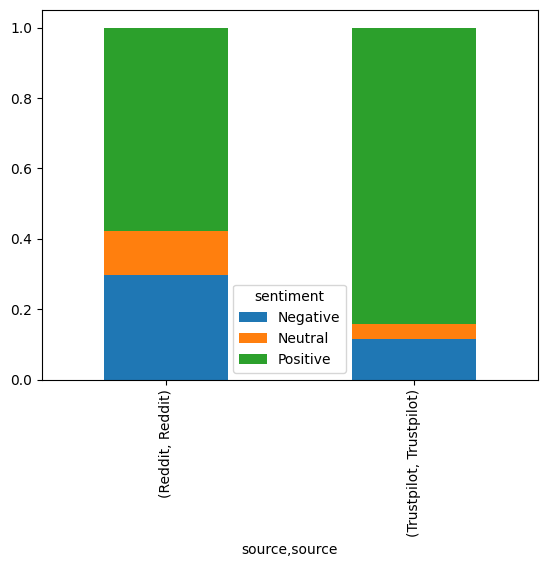

In [ ]:
comparison_pct = df.groupby(['source', 'sentiment']).size().groupby(level=0).apply(lambda x: x / x.sum())

comparison_pct.unstack().plot(kind='bar', stacked=True)

In [ ]:
df_filtered = df[df['bertopic'] != -1]

In [ ]:
df['bertopic'].value_counts()

,count
bertopic,
-1,1021
0,141
1,131
2,115
3,105
4,101
5,93
6,64
7,61


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data
final_df = pd.read_csv('final_dataset.csv')

# Calculate sentiment by topic (Topics 0-7 only)
topic_sentiment = final_df[final_df['topic'].isin(range(8))].groupby(['topic', 'sentiment']).size().unstack(fill_value=0)

# Calculate percentages and net sentiment
topic_metrics = pd.DataFrame()
for topic in range(8):
    total = topic_sentiment.loc[topic].sum()
    pos_pct = (topic_sentiment.loc[topic, 'Positive'] / total * 100) if 'Positive' in topic_sentiment.columns else 0
    neg_pct = (topic_sentiment.loc[topic, 'Negative'] / total * 100) if 'Negative' in topic_sentiment.columns else 0
    neu_pct = (topic_sentiment.loc[topic, 'Neutral'] / total * 100) if 'Neutral' in topic_sentiment.columns else 0

    topic_metrics.loc[topic, 'pos'] = pos_pct
    topic_metrics.loc[topic, 'neg'] = neg_pct
    topic_metrics.loc[topic, 'neu'] = neu_pct
    topic_metrics.loc[topic, 'net'] = pos_pct - neg_pct
    topic_metrics.loc[topic, 'docs'] = total
    topic_metrics.loc[topic, 'pct'] = total / len(final_df) * 100

# Topic names
topic_names = {
    0: 'App Technical\nIssues',
    1: 'Customer\nSupport',
    2: 'App\nUsability',
    3: 'Currency\nExchange',
    4: 'Banking\nComparisons',
    5: 'Account\nManagement',
    6: 'Travel\nConnectivity',
    7: 'Premium\nFeatures'
}

# Prepare plot data
x_values = topic_metrics['pct'].values
y_values = topic_metrics['net'].values
sizes = topic_metrics['docs'].values * 4
colors = ['#27ae60' if net > 30 else '#2ecc71' if net > 0 else '#e67e22' if net > -30 else '#e74c3c'
          for net in y_values]

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Scatter plot
scatter = ax.scatter(x_values, y_values, s=sizes, c=colors,
                     alpha=0.7, edgecolors='black', linewidth=2.5, zorder=3)

# Add topic labels
for i, (x, y) in enumerate(zip(x_values, y_values)):
    if i == 1:  # Topic 1 - emphasize
        offset_x, offset_y = -15, -25
        fontsize, bbox_color = 11, '#ffcccc'
        arrow = True
    elif i in [2, 3]:  # Topics 2, 3 - emphasize
        offset_x, offset_y = 10, 15 if i == 2 else -25
        fontsize, bbox_color = 10, '#ccffcc'
        arrow = True
    else:
        offset_x, offset_y = 8, 8
        fontsize, bbox_color = 9, 'white'
        arrow = False

    ax.annotate(f"Topic {i}\n{topic_names[i]}",
                xy=(x, y),
                xytext=(offset_x, offset_y),
                textcoords='offset points',
                fontsize=fontsize,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=bbox_color,
                         edgecolor='black', alpha=0.8, linewidth=1.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2',
                               color='black', lw=1.5) if arrow else None,
                zorder=4)

# Quadrant lines
median_prevalence = np.median(x_values)
ax.axhline(y=0, color='#34495e', linestyle='-', linewidth=2.5, alpha=0.8, zorder=1)
ax.axvline(x=median_prevalence, color='#34495e', linestyle='-', linewidth=2.5, alpha=0.8, zorder=1)

# Quadrant labels
quadrant_style = dict(fontsize=13, ha='center', va='center', fontweight='bold')

ax.text(5.5, 70, 'LEVERAGE\nOPPORTUNITIES',
        bbox=dict(boxstyle='round,pad=1', facecolor='#d5f4e6',
                 edgecolor='#27ae60', alpha=0.7, linewidth=3),
        **quadrant_style, color='#27ae60', zorder=2)

ax.text(5.5, -50, 'URGENT\nACTION REQUIRED',
        bbox=dict(boxstyle='round,pad=1', facecolor='#fadbd8',
                 edgecolor='#e74c3c', alpha=0.7, linewidth=3),
        **quadrant_style, color='#c0392b', zorder=2)

ax.text(3.2, 70, 'NICHE\nSTRENGTHS',
        bbox=dict(boxstyle='round,pad=1', facecolor='#fef9e7',
                 edgecolor='#f39c12', alpha=0.7, linewidth=3),
        **quadrant_style, color='#d68910', zorder=2)

ax.text(3.2, -50, 'MONITOR',
        bbox=dict(boxstyle='round,pad=1', facecolor='#eaecee',
                 edgecolor='#7f8c8d', alpha=0.7, linewidth=3),
        **quadrant_style, color='#566573', zorder=2)

# Formatting
ax.set_xlabel('Topic Prevalence (% of Dataset)', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('Net Sentiment (% Positive − % Negative)', fontsize=14, fontweight='bold', labelpad=10)
ax.set_title('Strategic Topic Prioritization Matrix\nPrevalence vs Sentiment Analysis',
             fontsize=16, fontweight='bold', pad=20)

ax.set_xlim(2.2, 6.8)
ax.set_ylim(-75, 90)
ax.grid(True, alpha=0.25, linestyle=':', linewidth=1, zorder=0)
ax.set_axisbelow(True)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Strongly Positive (net >30%)',
           markerfacecolor='#27ae60', markersize=12, markeredgecolor='black', markeredgewidth=2),
    Line2D([0], [0], marker='o', color='w', label='Moderately Positive (net 0-30%)',
           markerfacecolor='#2ecc71', markersize=12, markeredgecolor='black', markeredgewidth=2),
    Line2D([0], [0], marker='o', color='w', label='Mixed (net -30 to 0%)',
           markerfacecolor='#e67e22', markersize=12, markeredgecolor='black', markeredgewidth=2),
    Line2D([0], [0], marker='o', color='w', label='Negative (net <-30%)',
           markerfacecolor='#e74c3c', markersize=12, markeredgecolor='black', markeredgewidth=2),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=True,
          fancybox=True, shadow=True, fontsize=10, title='Net Sentiment', title_fontsize=11)

ax.text(0.98, 0.02, 'Bubble size represents document count',
        transform=ax.transAxes, fontsize=10, ha='right', va='bottom', style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5, pad=0.5))

# Key insight
ax.annotate(f'Topic 1: High visibility\n+ severe negativity\n= Critical priority',
            xy=(x_values[1], y_values[1]), xytext=(4.8, -25),
            fontsize=9, ha='center',
            bbox=dict(boxstyle='round', facecolor='#ffe6e6',
                     edgecolor='red', alpha=0.8, linewidth=2),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5,
                           connectionstyle='arc3,rad=-0.3'))

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/sentiment_volume_matrix.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Figure 6: Sentiment-Volume Matrix saved!")
print(f"\n📊 Topic Metrics:")
print(topic_metrics.round(1))

KeyError: 'topic'